In [118]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from game import BBTAN
from aimbot import get_aimbot_move

# Aimbot - best model

In [119]:
# env setup
aimbot = BBTAN(render_mode=False)
done = False
# Predef var
MAX_LEVEL = 600
COLS = 7
MAX_ROWS = 10
# Data holder
records = []

In [120]:
while not done and aimbot.level <= MAX_LEVEL:
    # Basic stats
    curr_state = aimbot.get_params()
    
    best_angle = get_aimbot_move(aimbot)
    curr_state['Target_Angle'] = best_angle
    
    # training params 
    curr_state['Start_X'] = aimbot.start_x
    
    for r in range(MAX_ROWS):
        for c in range(COLS):
            curr_state[f'R{r}_C{c}'] = 0
            
    for b in aimbot.blocks:
        if 0 <= b.row < MAX_ROWS and 0 <= b.col < COLS:
            curr_state[f'R{b.row}_C{b.col}'] = b.hp
            
    records.append(curr_state)
    
    if records[-1]['Level'] % 10 == 0:
        print(f"Level {records[-1]['Level']} | Blocks: {records[-1]['Blocks']} | HP: {records[-1]['Blocks_HP']} | Floor: {records[-1]['Floor']}")

    _, _, done, _ = aimbot.step(best_angle)

Level 10 | Blocks: 4 | HP: 36 | Floor: 10
Level 20 | Blocks: 4 | HP: 58 | Floor: 9
Level 30 | Blocks: 2 | HP: 31 | Floor: 9
Level 40 | Blocks: 5 | HP: 165 | Floor: 9
Level 50 | Blocks: 4 | HP: 196 | Floor: 10
Level 60 | Blocks: 6 | HP: 321 | Floor: 9
Level 70 | Blocks: 4 | HP: 172 | Floor: 9
Level 80 | Blocks: 3 | HP: 237 | Floor: 10
Level 90 | Blocks: 4 | HP: 356 | Floor: 10
Level 100 | Blocks: 4 | HP: 316 | Floor: 7
Level 110 | Blocks: 5 | HP: 545 | Floor: 10
Level 120 | Blocks: 8 | HP: 643 | Floor: 9
Level 130 | Blocks: 2 | HP: 258 | Floor: 10
Level 140 | Blocks: 4 | HP: 556 | Floor: 10
Level 150 | Blocks: 6 | HP: 765 | Floor: 9
Level 160 | Blocks: 5 | HP: 795 | Floor: 10
Level 170 | Blocks: 4 | HP: 603 | Floor: 9
Level 180 | Blocks: 5 | HP: 895 | Floor: 10
Level 190 | Blocks: 4 | HP: 756 | Floor: 10
Level 200 | Blocks: 5 | HP: 995 | Floor: 10
Level 210 | Blocks: 4 | HP: 604 | Floor: 9
Level 220 | Blocks: 2 | HP: 438 | Floor: 10
Level 230 | Blocks: 3 | HP: 687 | Floor: 10
Level 240 

In [132]:
df = pd.DataFrame(records)
df.info()
df
os.makedirs("data", exist_ok=True)
df.to_csv("data/bbtan_training_data.csv", mode='a', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 76 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Level         599 non-null    int64  
 1   Floor         599 non-null    int64  
 2   Blocks        599 non-null    int64  
 3   Blocks_HP     599 non-null    int64  
 4   Target_Angle  599 non-null    float64
 5   Start_X       599 non-null    float64
 6   R0_C0         599 non-null    int64  
 7   R0_C1         599 non-null    int64  
 8   R0_C2         599 non-null    int64  
 9   R0_C3         599 non-null    int64  
 10  R0_C4         599 non-null    int64  
 11  R0_C5         599 non-null    int64  
 12  R0_C6         599 non-null    int64  
 13  R1_C0         599 non-null    int64  
 14  R1_C1         599 non-null    int64  
 15  R1_C2         599 non-null    int64  
 16  R1_C3         599 non-null    int64  
 17  R1_C4         599 non-null    int64  
 18  R1_C5         599 non-null    

In [135]:
df_train = pd.read_csv("data/bbtan_training_data.csv")

# Sprawdźmy, co odczytał!
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 76 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Level         1259 non-null   object
 1   Floor         1259 non-null   object
 2   Blocks        1259 non-null   object
 3   Blocks_HP     1259 non-null   object
 4   Target_Angle  1259 non-null   object
 5   Start_X       1259 non-null   object
 6   R0_C0         1259 non-null   object
 7   R0_C1         1259 non-null   object
 8   R0_C2         1259 non-null   object
 9   R0_C3         1259 non-null   object
 10  R0_C4         1259 non-null   object
 11  R0_C5         1259 non-null   object
 12  R0_C6         1259 non-null   object
 13  R1_C0         1259 non-null   object
 14  R1_C1         1259 non-null   object
 15  R1_C2         1259 non-null   object
 16  R1_C3         1259 non-null   object
 17  R1_C4         1259 non-null   object
 18  R1_C5         1259 non-null   object
 19  R1_C6 

In [136]:
aimbot_df = pd.DataFrame(records, columns=['Level', 'Floor', 'Blocks', 'Blocks_HP'])
aimbot_df.info()
aimbot_df
os.makedirs("data", exist_ok=True)
aimbot_df.to_csv("data/aimbot_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Level      599 non-null    int64
 1   Floor      599 non-null    int64
 2   Blocks     599 non-null    int64
 3   Blocks_HP  599 non-null    int64
dtypes: int64(4)
memory usage: 18.8 KB


In [137]:
aimbot_df = pd.read_csv("data/aimbot_data.csv")

In [138]:
aimbot_df.describe()

,Level,Floor,Blocks,Blocks_HP
count,599.000000,599.000000,599.000000,599.000000
mean,301.000000,9.437396,4.170284,1123.629382
std,173.060683,0.709942,1.604045,796.244733
min,2.000000,7.000000,0.000000,0.000000
25%,151.500000,9.000000,3.000000,492.000000
50%,301.000000,10.000000,4.000000,984.000000
75%,450.500000,10.000000,5.000000,1668.500000
max,600.000000,10.000000,9.000000,3742.000000


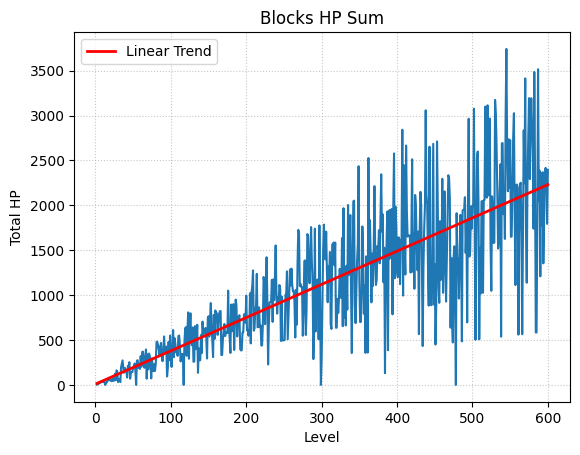

In [139]:
plt.plot(aimbot_df['Level'], aimbot_df['Blocks_HP'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Blocks_HP'], 1)
aimbot_poly_Blocks_HP = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks_HP(aimbot_df['Level']), color='red', linewidth=2, label='Linear Trend')
plt.title("Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

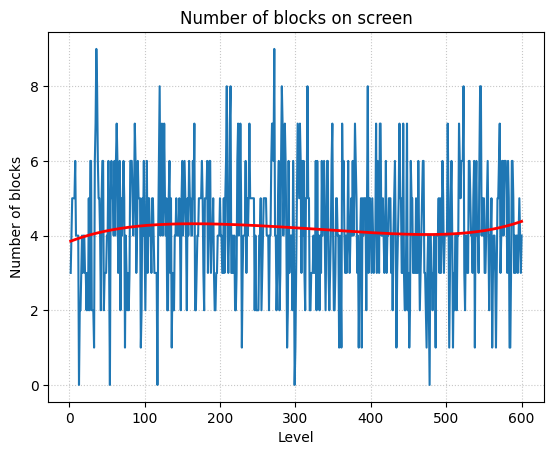

In [140]:
plt.plot(aimbot_df['Level'], aimbot_df['Blocks'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Blocks'], 5)
aimbot_poly_Blocks = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks(aimbot_df['Level']), color='red', linewidth=2, label='Quadratic Trend')
plt.title("Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

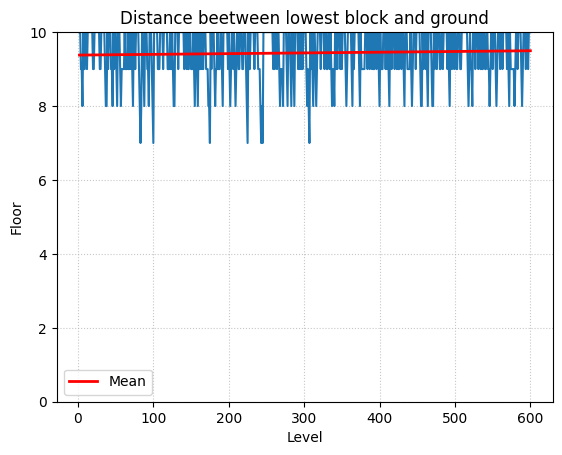

In [141]:
plt.plot(aimbot_df['Level'], aimbot_df['Floor'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Floor'], 1)
aimbot_poly_Floor = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Floor(aimbot_df['Level']), color='red', linewidth=2, label='Mean')
plt.title("Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Randombot

In [142]:
from agent import get_random_bot_move

In [184]:
random_game = BBTAN(render_mode=False)
done = False
records_random = []
MAX_LEVEL = 600

In [185]:
while not done and random_game.level <= MAX_LEVEL:
    state = random_game.get_params()
    records_random.append(state)
    random_angle = get_random_bot_move()
    _, _, done, _ = random_game.step(random_angle)

In [186]:
random_df = pd.DataFrame(records_random, columns=['Level', 'Floor', 'Blocks', 'Blocks_HP'])
random_df.info()
random_df
os.makedirs("data", exist_ok=True)
random_df.to_csv("data/random_bot_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Level      113 non-null    int64
 1   Floor      113 non-null    int64
 2   Blocks     113 non-null    int64
 3   Blocks_HP  113 non-null    int64
dtypes: int64(4)
memory usage: 3.7 KB


In [187]:
random_df = pd.read_csv("data/random_bot_data.csv")

In [188]:
random_df.describe()

,Level,Floor,Blocks,Blocks_HP
count,113.00000,113.000000,113.000000,113.000000
mean,58.00000,6.035398,10.752212,512.168142
std,32.76431,2.013034,4.479180,384.696701
min,2.00000,2.000000,1.000000,3.000000
25%,30.00000,5.000000,8.000000,198.000000
50%,58.00000,6.000000,10.000000,428.000000
75%,86.00000,7.000000,13.000000,761.000000
max,114.00000,10.000000,25.000000,1492.000000


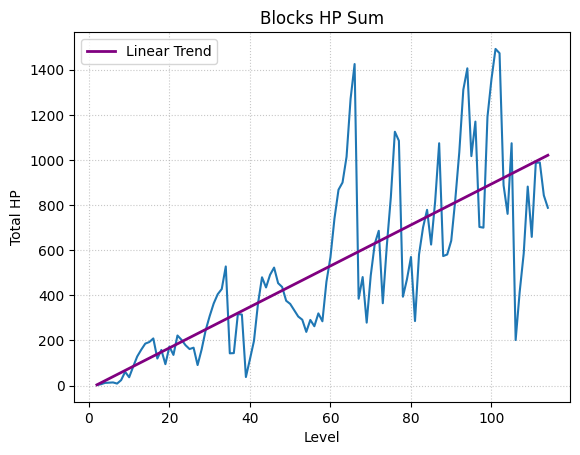

In [189]:
plt.plot(random_df['Level'], random_df['Blocks_HP'])
a = np.polyfit(random_df['Level'], random_df['Blocks_HP'], 1)
randombot_poly_Blocks_HP = np.poly1d(a)
plt.plot(random_df['Level'], randombot_poly_Blocks_HP(random_df['Level']), color='purple', linewidth=2, label='Linear Trend')
plt.title("Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

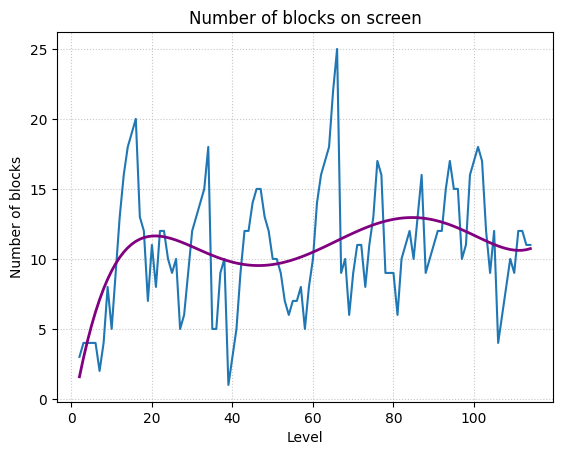

In [ ]:
plt.plot(random_df['Level'], random_df['Blocks'])
a = np.polyfit(random_df['Level'], random_df['Blocks'], 5)
randombot_poly_Blocks = np.poly1d(a)
plt.plot(random_df['Level'], randombot_poly_Blocks(random_df['Level']), color='purple', linewidth=2, label='Quadratic Trend')
plt.title("Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

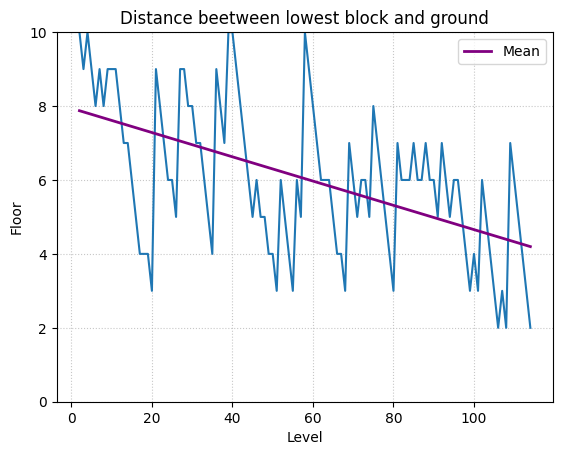

In [191]:
plt.plot(random_df['Level'], random_df['Floor'])
a = np.polyfit(random_df['Level'], random_df['Floor'], 1)
randombot_poly_Floor = np.poly1d(a)
plt.plot(random_df['Level'], randombot_poly_Floor(random_df['Level']), color='purple', linewidth=2, label='Mean')
plt.title("Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Rainforced Agent

In [198]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from agent import BBTANGymEnv, get_reinforce_agent_move

### Training set

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./ppo_bbtan_tensorboard/
#to open in browser use: http://localhost:6006/

Reusing TensorBoard on port 6006 (pid 5688), started 2:44:33 ago. (Use '!kill 5688' to kill it.)

In [200]:
train_env = BBTANGymEnv(render_mode=False)

# Ścieżka do modelu, z którego wznawiamy trening (bez .zip)
model_path = "models/bbtan_checkpoint_v2_66200_steps" 

print(f"Wczytywanie starego modelu z {model_path}.zip...")
model = PPO.load(model_path, env=train_env, tensorboard_log="./ppo_bbtan_tensorboard/")
    
TIMESTEPS = 5000 # Ile KOLEJNYCH kroków chcemy go douczyć
    
checkpoint_callback = CheckpointCallback(
    save_freq=5000, 
    save_path='./models/',
    # Uniwersalny prefix. Zapisze plik np. jako 'bbtan_checkpoint_71200_steps.zip'
    name_prefix='bbtan_checkpoint' 
)
    
try:
    model.learn(total_timesteps=TIMESTEPS, callback=checkpoint_callback, reset_num_timesteps=False)
    
except KeyboardInterrupt:
    print("\nPrzerwano ręcznie! Zapisuję obecny stan...")
    
finally:
    # Main model
    final_model_path = "models/ppo_bbtan_model"
    model.save(final_model_path)
    
    print(f"Gotowe! Główny model zaktualizowany i zapisany jako: {final_model_path}.zip")
    train_env.close()

Wczytywanie starego modelu z models/bbtan_checkpoint_v2_66200_steps.zip...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./ppo_bbtan_tensorboard/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 721      |
|    ep_rew_mean     | 1.54e+05 |
| time/              |          |
|    fps             | 4        |
|    iterations      | 1        |
|    time_elapsed    | 466      |
|    total_timesteps | 68248    |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 726           |
|    ep_rew_mean          | 1.54e+05      |
| time/                   |               |
|    fps                  | 4             |
|    iterations           | 2             |
|    time_elapsed         | 938           |
|    total_timesteps      | 70296         |
| train/                  |               |
|    approx_kl            |

### Test set

In [201]:
# env setup
reinforce_agent = BBTAN(render_mode=False)
model = PPO.load("models/ppo_bbtan_model.zip")
translator_env = BBTANGymEnv(render_mode=False)
done = False
# Predef var
MAX_LEVEL = 600
# Data holder
records = []

In [203]:
while not done and reinforce_agent.level <= MAX_LEVEL:
    # Zbieramy statystyki planszy i DODAJEmy do listy
    obecny_stan = reinforce_agent.get_params()
    records.append(obecny_stan)

    if obecny_stan['Level'] % 10 == 0:
        print(f"Level {obecny_stan['Level']} | Blocks: {obecny_stan['Blocks']} | HP: {obecny_stan['Blocks_HP']} | Floor: {obecny_stan['Floor']}")

    # Agent PPO podejmuje decyzję
    best_angle = get_reinforce_agent_move(reinforce_agent, model, translator_env)
    
    # Gra wykonuje ruch
    _, _, done, _ = reinforce_agent.step(best_angle)

Level 10 | Blocks: 4 | HP: 36 | Floor: 10
Level 20 | Blocks: 11 | HP: 138 | Floor: 7
Level 30 | Blocks: 5 | HP: 143 | Floor: 9
Level 40 | Blocks: 4 | HP: 156 | Floor: 10
Level 50 | Blocks: 2 | HP: 98 | Floor: 10
Level 60 | Blocks: 5 | HP: 295 | Floor: 10
Level 70 | Blocks: 13 | HP: 760 | Floor: 8
Level 80 | Blocks: 5 | HP: 282 | Floor: 8
Level 90 | Blocks: 7 | HP: 441 | Floor: 7
Level 100 | Blocks: 9 | HP: 762 | Floor: 9
Level 110 | Blocks: 7 | HP: 657 | Floor: 9
Level 120 | Blocks: 13 | HP: 1449 | Floor: 6
Level 130 | Blocks: 17 | HP: 2034 | Floor: 7
Level 140 | Blocks: 4 | HP: 555 | Floor: 9
Level 150 | Blocks: 10 | HP: 1428 | Floor: 8
Level 160 | Blocks: 4 | HP: 547 | Floor: 8
Level 170 | Blocks: 3 | HP: 507 | Floor: 10
Level 180 | Blocks: 13 | HP: 2210 | Floor: 6
Level 190 | Blocks: 11 | HP: 1630 | Floor: 7
Level 200 | Blocks: 4 | HP: 599 | Floor: 7
Level 210 | Blocks: 7 | HP: 1129 | Floor: 8
Level 220 | Blocks: 11 | HP: 2340 | Floor: 7
Level 230 | Blocks: 5 | HP: 914 | Floor: 9
Le

In [204]:
reinforce_agent_df = pd.DataFrame(records)
reinforce_agent_df.info()
reinforce_agent_df
reinforce_agent_df.describe()
os.makedirs("data", exist_ok=True)
reinforce_agent_df.to_csv("data/reinforce_agent_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Level      599 non-null    int64
 1   Floor      599 non-null    int64
 2   Blocks     599 non-null    int64
 3   Blocks_HP  599 non-null    int64
dtypes: int64(4)
memory usage: 18.8 KB


In [205]:
reinforce_agent_df = pd.read_csv("data/reinforce_agent_data.csv")

In [206]:
reinforce_agent_df.describe()

,Level,Floor,Blocks,Blocks_HP
count,599.000000,599.000000,599.000000,599.000000
mean,301.000000,8.654424,7.181970,2001.724541
std,173.060683,1.201633,4.027739,1669.700406
min,2.000000,4.000000,1.000000,4.000000
25%,151.500000,8.000000,4.000000,754.500000
50%,301.000000,9.000000,6.000000,1635.000000
75%,450.500000,10.000000,9.000000,2858.000000
max,600.000000,10.000000,24.000000,10308.000000


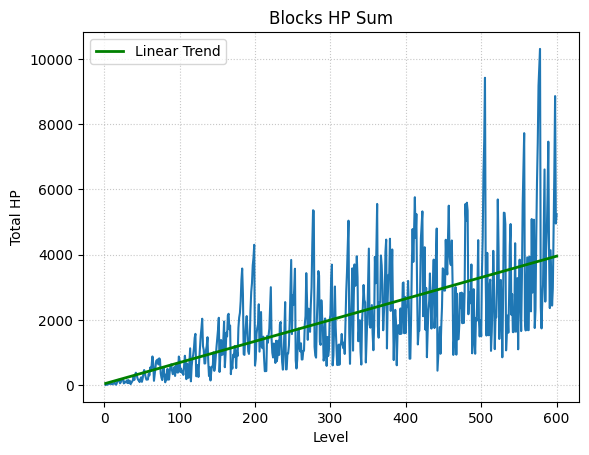

In [207]:
plt.plot(reinforce_agent_df['Level'], reinforce_agent_df['Blocks_HP'])
a = np.polyfit(reinforce_agent_df['Level'], reinforce_agent_df['Blocks_HP'], 1)
reinforce_agent_poly_Blocks_HP = np.poly1d(a)
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Blocks_HP(reinforce_agent_df['Level']), color='green', linewidth=2, label='Linear Trend')
plt.title("Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

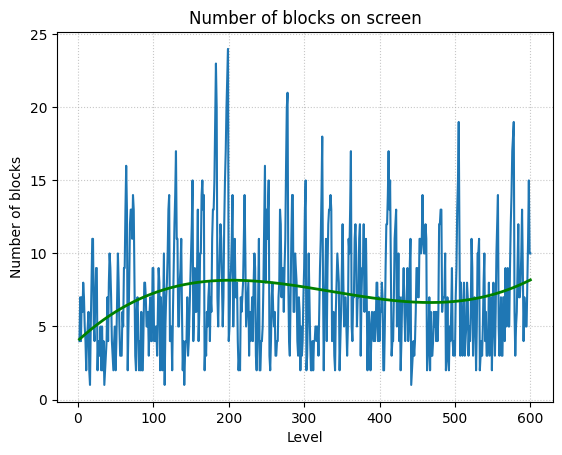

In [216]:
plt.plot(reinforce_agent_df['Level'], reinforce_agent_df['Blocks'])
a = np.polyfit(reinforce_agent_df['Level'], reinforce_agent_df['Blocks'], 3)
reinforce_agent_poly_Blocks = np.poly1d(a)
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Blocks(reinforce_agent_df['Level']), color='green', linewidth=2, label='Quadratic Trend')
plt.title("Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

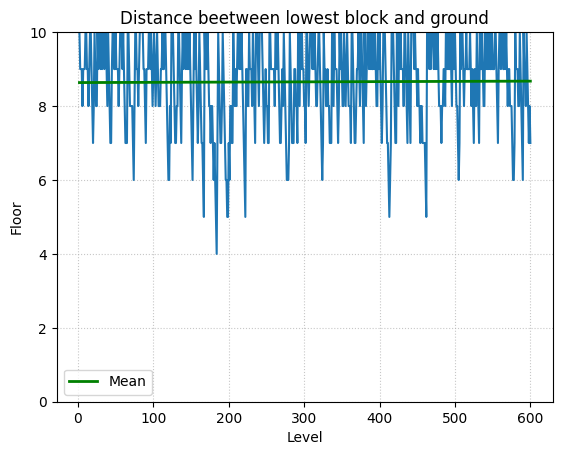

In [211]:
plt.plot(reinforce_agent_df['Level'], reinforce_agent_df['Floor'])
a = np.polyfit(reinforce_agent_df['Level'], reinforce_agent_df['Floor'], 1)
reinforce_agent_poly_Floor = np.poly1d(a)
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Floor(reinforce_agent_df['Level']), color='green', linewidth=2, label='Mean')
plt.title("Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Supervised agent 

In [212]:
import math
import joblib
from agent import get_supervised_agent_move
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

### Training set prep

In [7]:
df_train = pd.read_csv("data/bbtan_training_data.csv")
del_cols = ['Target_Angle', 'Level', 'Floor', 'Blocks', 'Blocks_HP']
X = df_train.drop(columns=del_cols)
Y = df_train['Target_Angle']
df_train

,Level,Floor,Blocks,Blocks_HP,Target_Angle,Start_X,R0_C0,R0_C1,R0_C2,R0_C3,...,R8_C4,R8_C5,R8_C6,R9_C0,R9_C1,R9_C2,R9_C3,R9_C4,R9_C5,R9_C6
0,2,10,5,5,-0.349066,200.000000,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,3,9,5,8,-0.436332,355.565655,0,2,2,0,...,0,0,0,0,0,0,0,0,0,0
2,4,9,3,7,-0.261799,187.361825,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
3,5,10,0,0,-0.261799,133.502209,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6,10,3,15,-0.523599,254.906681,5,5,0,0,...,0,0,0,0,0,0,0,0,0,0
5,7,9,2,11,-0.261799,213.846097,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0
6,8,10,6,42,-2.443461,295.777748,7,7,7,7,...,0,0,0,0,0,0,0,0,0,0
7,9,10,5,40,-2.792527,300.161066,8,8,8,0,...,0,0,0,0,0,0,0,0,0,0
8,10,10,2,18,-0.872665,6.000000,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
9,11,10,5,50,-0.261799,353.105309,0,10,10,10,...,0,0,0,0,0,0,0,0,0,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
sl_model = RandomForestRegressor(n_estimators=100, random_state=42)
sl_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
predictions = sl_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

In [11]:
model_path = "models/supervised_bbtan_model.pkl"
joblib.dump(sl_model, model_path)
print(f"Zapisano model SL w: {model_path}")

Zapisano model SL w: models/supervised_bbtan_model.pkl


In [12]:
sl_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
sl_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### test

In [13]:
sl_model = joblib.load("models/supervised_bbtan_model.pkl")

In [22]:
sl_agent_game = BBTAN(render_mode=False)
done = False
records_sl = []
wyniki_koncowe = []
MAX_LEVEL = 600

In [45]:
for i in range(1000):
    sl_agent_game.reset() 
    done = False
    records_sl = []
    while not done and sl_agent_game.level <= MAX_LEVEL:
        obecny_stan = sl_agent_game.get_params()
        records_sl.append(obecny_stan)

        best_angle = get_supervised_agent_move(sl_agent_game, sl_model)
        _, _, done, _ = sl_agent_game.step(best_angle)
        
    if sl_agent_game.level > 50:
        break
    
supervised_df = pd.DataFrame(records_sl)
#display(df_sl.head())

In [ ]:
supervised_df.to_csv("supervised_bot_data.csv")

In [42]:
for i in range(100):
    sl_agent_game.reset() 
    done = False
    
    while not done and sl_agent_game.level <= MAX_LEVEL:
        obecny_stan = sl_agent_game.get_params()
        records_sl.append(obecny_stan)

        best_angle = get_supervised_agent_move(sl_agent_game, sl_model)
        _, _, done, _ = sl_agent_game.step(best_angle)
        
        if done:
            poziom_przegranej = obecny_stan['Level']
            wyniki_koncowe.append(poziom_przegranej) # Zapisujemy do listy

df_sl = pd.DataFrame(records_sl)
#display(df_sl.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       100 non-null    int64
dtypes: int64(1)
memory usage: 928.0 bytes


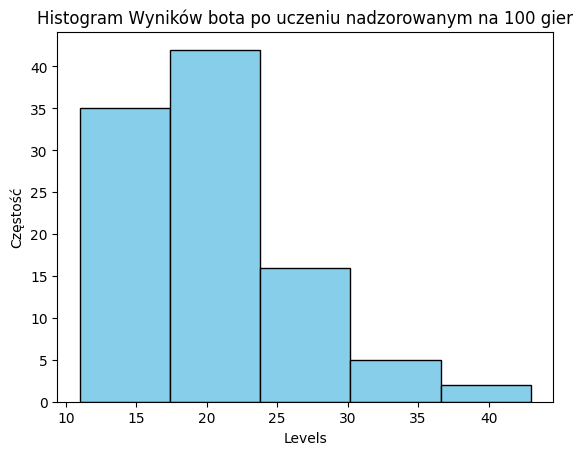

In [ ]:
# Podsumowanie całego eksperymentu
ds = pd.DataFrame(wyniki_koncowe)
ds.hist(bins=5, color='skyblue', edgecolor='black', grid=False)
plt.title('Histogram Wyników bota po uczeniu nadzorowanym na 100 gier')
plt.xlabel('Levels')
plt.ylabel('Częstość')
plt.show()

In [33]:
ds.describe()

,0
count,100.000000
mean,20.370000
std,6.032998
min,11.000000
25%,16.000000
50%,19.500000
75%,23.000000
max,43.000000


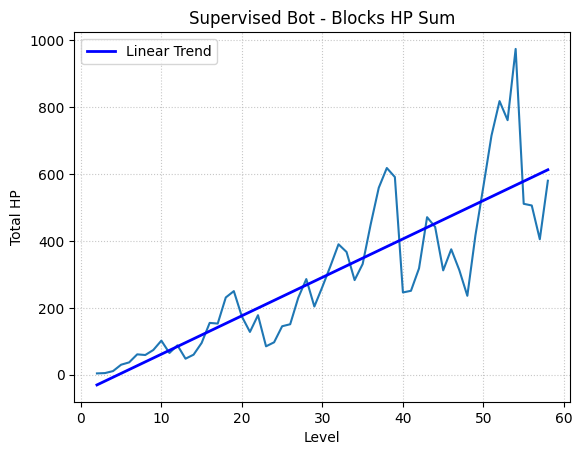

In [103]:
plt.plot(supervised_df['Level'], supervised_df['Blocks_HP'])
a = np.polyfit(supervised_df['Level'], supervised_df['Blocks_HP'], 1)
supervised_poly_Blocks_HP = np.poly1d(a)
plt.plot(supervised_df['Level'], supervised_poly_Blocks_HP(supervised_df['Level']), color='blue', linewidth=2, label='Linear Trend')
plt.title("Supervised Bot - Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

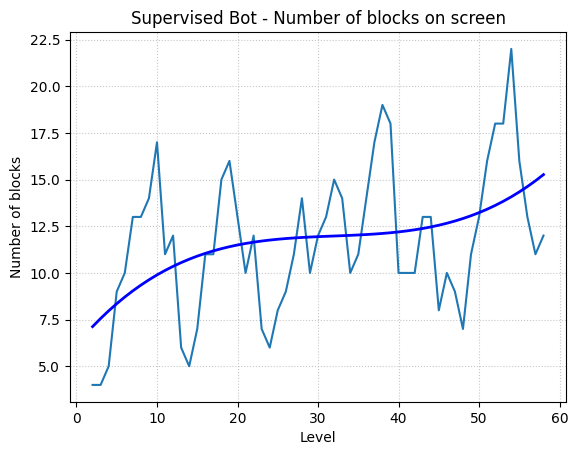

In [104]:
plt.plot(supervised_df['Level'], supervised_df['Blocks'])
a = np.polyfit(supervised_df['Level'], supervised_df['Blocks'], 3)
supervised_poly_Blocks = np.poly1d(a)
plt.plot(supervised_df['Level'], supervised_poly_Blocks(supervised_df['Level']), color='blue', linewidth=2, label='Quadratic Trend')
plt.title("Supervised Bot - Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

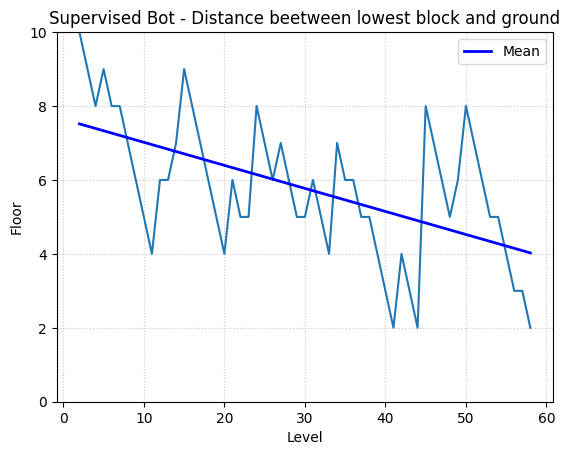

In [105]:
plt.plot(supervised_df['Level'], supervised_df['Floor'])
a = np.polyfit(supervised_df['Level'], supervised_df['Floor'], 1)
supervised_poly_Floor = np.poly1d(a)
plt.plot(supervised_df['Level'], supervised_poly_Floor(supervised_df['Level']), color='blue', linewidth=2, label='Mean')
plt.title("Supervised Bot - Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Comparision

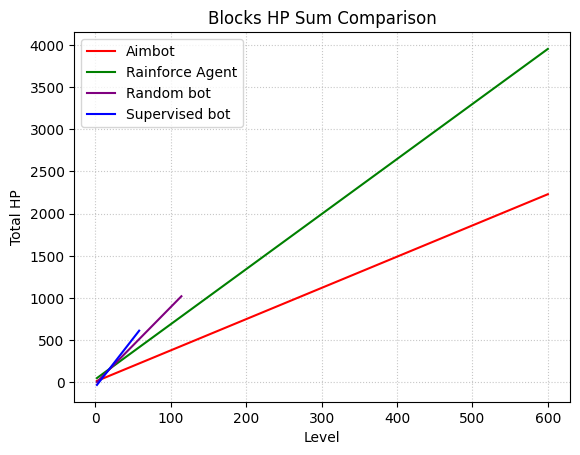

In [213]:
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks_HP(aimbot_df['Level']), color = 'red', label='Aimbot')
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Blocks_HP(reinforce_agent_df['Level']), color = 'green', label='Rainforce Agent')
plt.plot(random_df['Level'], randombot_poly_Blocks_HP(random_df['Level']), color = 'purple', label='Random bot')
plt.plot(supervised_df['Level'], supervised_poly_Blocks_HP(supervised_df['Level']), color = 'blue', label='Supervised bot')
plt.title("Blocks HP Sum Comparison")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

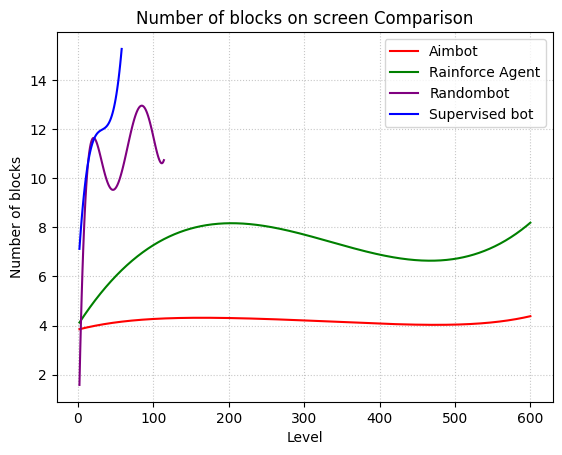

In [217]:
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks(aimbot_df['Level']), color = 'red', label='Aimbot')
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Blocks(reinforce_agent_df['Level']), color = 'green', label='Rainforce Agent')
plt.plot(random_df['Level'], randombot_poly_Blocks(random_df['Level']), color = 'purple', label='Randombot')
plt.plot(supervised_df['Level'], supervised_poly_Blocks(supervised_df['Level']), color = 'blue', label='Supervised bot')
plt.title("Number of blocks on screen Comparison")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

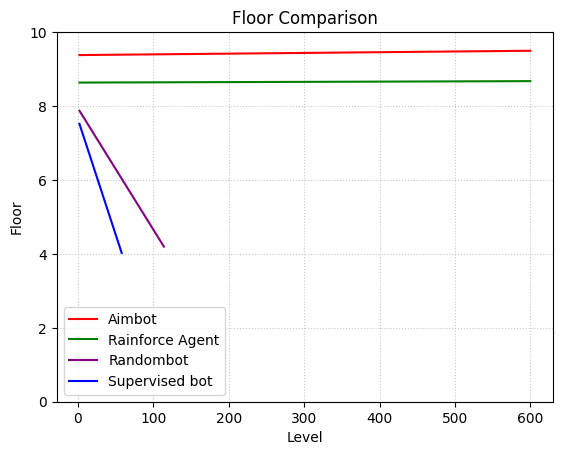

In [215]:
plt.plot(aimbot_df['Level'], aimbot_poly_Floor(aimbot_df['Level']), color = 'red', label='Aimbot')
plt.plot(reinforce_agent_df['Level'], reinforce_agent_poly_Floor(reinforce_agent_df['Level']), color = 'green', label='Rainforce Agent')
plt.plot(random_df['Level'], randombot_poly_Floor(random_df['Level']), color = 'purple', label='Randombot')
plt.plot(supervised_df['Level'], supervised_poly_Floor(supervised_df['Level']), color = 'blue', label='Supervised bot')
plt.title("Floor Comparison")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)